# 机器学习模型对TEACHBEHA特征预测的比较实验

中国科大2025年春季学期"数据分析及实践"课程

## 实验目的

本实验旨在比较不同机器学习模型对TEACHBEHA特征的预测效果，具体目标包括：

1. 使用SelectKBest(k=10)方法进行特征选择
2. 比较不同机器学习模型的预测效果
3. 对表现最佳的两种模型进行参数调优
4. 分析各模型的适用性和优缺点

In [2]:
# 导入所需库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 机器学习模型和工具
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression

# 设置可视化风格
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

## 1. 数据加载与预处理

In [3]:
# 读取数据集
df = pd.read_csv('/Users/halo/Desktop/数据分析及实践实验/实验5/subdata.csv', index_col=0)

# 显示数据集基本信息
print(f"数据集形状: {df.shape}")
print("\n数据集前5行:")
display(df.head())

# 数据类型和缺失值统计
info_df = pd.DataFrame({
    '数据类型': df.dtypes,
    '非空值数量': df.count(),
    '缺失值数量': df.isnull().sum(),
    '缺失比例': df.isnull().sum() / len(df) * 100
})
display(info_df)

数据集形状: (1089, 25)

数据集前5行:


,CNTSCHID,Region,STRATUM,LANGTEST,PRIVATESCH,SCHLTYPE,STRATIO,SCHSIZE,RATCMP1,RATCMP2,TOTAT,PROATCE,PROAT5AB,PROAT5AM,PROAT6,CLSIZE,CREACTIV,EDUSHORT,STAFFSHORT,STUBEHA,TEACHBEHA,SCMCEG,W_SCHGRNRABWT,W_FSTUWT_SCH_SUM,SENWT
0,72400001,72413,ESP9028,156.0,private,2.0,1.2000,75.0,NaN,1.0,62.5,1.0,0.8400,0.1120,0.0480,28.0,0.0,1.0283,1.0953,-0.6266,-0.1274,-0.1868,9.44357,796.01006,6.85830
1,72400002,72415,ESP1532,156.0,public,3.0,7.6379,443.0,0.7143,1.0,58.0,1.0,1.0000,NaN,NaN,23.0,1.0,0.0686,0.4300,0.5078,1.1612,0.9042,1.56862,121.29469,1.13920
2,72400003,72409,ESP9018,156.0,private,1.0,10.4452,1572.0,0.2604,1.0,150.5,1.0,1.0000,0.1993,0.0199,23.0,1.0,-0.9490,-0.5869,-2.0719,-1.4190,0.9042,16.53833,1538.38583,12.01080
3,72400004,72406,ESP0611,156.0,public,3.0,12.6935,1574.0,0.0789,1.0,124.0,1.0,1.0000,0.0161,0.0806,23.0,2.0,0.4292,0.2633,-0.6744,0.2266,0.1571,1.54470,80.31823,1.12182
4,72400005,72417,ESP9038,156.0,public,3.0,9.5074,965.0,0.6329,1.0,101.5,1.0,0.8867,0.0936,0.0296,28.0,1.0,2.1861,1.5598,0.2913,-0.9033,0.2870,9.15181,975.57348,6.64641


,数据类型,非空值数量,缺失值数量,缺失比例
CNTSCHID,int64,1089,0,0.000000
Region,int64,1089,0,0.000000
STRATUM,object,1089,0,0.000000
LANGTEST,float64,1064,25,2.295684
PRIVATESCH,object,1089,0,0.000000
SCHLTYPE,float64,1040,49,4.499541
STRATIO,float64,977,112,10.284665
SCHSIZE,float64,988,101,9.274564
RATCMP1,float64,970,119,10.927456
RATCMP2,float64,1018,71,6.519743


TEACHBEHA 的描述性统计:


count    1054.000000
mean       -0.099276
std         0.967054
min        -2.090400
25%        -0.599275
50%        -0.117700
75%         0.601500
max         3.787900
Name: TEACHBEHA, dtype: float64

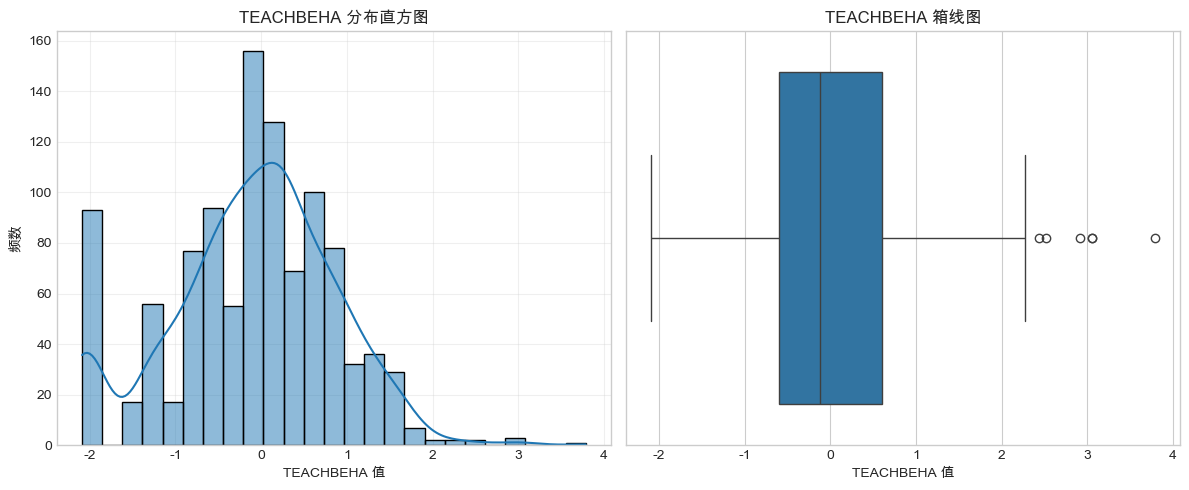

偏度: -0.1704
峰度: 0.1021


In [4]:
# 检查目标变量的统计特性和分布
print("TEACHBEHA 的描述性统计:")
display(df['TEACHBEHA'].describe())

# 可视化目标变量分布
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['TEACHBEHA'].dropna(), kde=True)
plt.title('TEACHBEHA 分布直方图')
plt.xlabel('TEACHBEHA 值')
plt.ylabel('频数')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(x=df['TEACHBEHA'].dropna())
plt.title('TEACHBEHA 箱线图')
plt.xlabel('TEACHBEHA 值')

plt.tight_layout()
plt.show()

# 检查偏度和峰度
skewness = df['TEACHBEHA'].dropna().skew()
kurtosis = df['TEACHBEHA'].dropna().kurt()
print(f"偏度: {skewness:.4f}")
print(f"峰度: {kurtosis:.4f}")

In [5]:
# 数据预处理: 处理缺失值和异常值

# 检查并删除常量列
constant_cols = df.columns[df.nunique() == 1]
if len(constant_cols) > 0:
    print(f"删除的常量列: {constant_cols.tolist()}")
    df = df.drop(columns=constant_cols)

# 处理目标变量缺失的行
df_clean = df.dropna(subset=['TEACHBEHA'])

# 检查是否有过多缺失值的列
missing_threshold = 30.0  # 超过30%的缺失值则删除该列
high_missing_cols = info_df[info_df['缺失比例'] > missing_threshold].index.tolist()
if high_missing_cols:
    print(f"删除的高缺失列: {high_missing_cols}")
    df_clean = df_clean.drop(columns=high_missing_cols)

# 处理剩余缺失值
numerical_cols = df_clean.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df_clean.select_dtypes(exclude=['number']).columns.tolist()

# 数值型特征使用均值填充
for col in numerical_cols:
    if col != 'TEACHBEHA' and df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mean())

# 分类特征使用众数填充
for col in categorical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# 检查处理后的缺失值情况
print(f"\n处理后数据集形状: {df_clean.shape}")
print(f"处理后缺失值总数: {df_clean.isnull().sum().sum()}")


处理后数据集形状: (1054, 25)
处理后缺失值总数: 0


/var/folders/s5/x61j5mg13qjcd3vpv32rjn6h0000gn/T/ipykernel_97331/2189705503.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[col] = df_clean[col].fillna(df_clean[col].mean())


## 2. 数据集划分与特征选择

In [6]:
# 准备特征和目标变量
y = df_clean['TEACHBEHA']
X_all = df_clean.drop('TEACHBEHA', axis=1)

# 处理分类特征 (使用独热编码)
X_encoded = pd.get_dummies(X_all, drop_first=True)

# 数据集划分 (70% 训练，15% 验证，15% 测试)
# 首先划分出测试集
X_temp, X_test, y_temp, y_test = train_test_split(
    X_encoded, y, test_size=0.15, random_state=42)

# 然后从剩下的数据中划分出训练集和验证集
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=42)

print(f"训练集形状: {X_train.shape}, {len(y_train)} 样本")
print(f"验证集形状: {X_val.shape}, {len(y_val)} 样本")
print(f"测试集形状: {X_test.shape}, {len(y_test)} 样本")

# 验证划分比例
total_samples = len(y)
train_ratio = len(y_train) / total_samples
val_ratio = len(y_val) / total_samples
test_ratio = len(y_test) / total_samples
print(f"\n实际划分比例:")
print(f"训练集: {train_ratio:.2f} ({len(y_train)}/{total_samples})")
print(f"验证集: {val_ratio:.2f} ({len(y_val)}/{total_samples})")
print(f"测试集: {test_ratio:.2f} ({len(y_test)}/{total_samples})")

训练集形状: (737, 96), 737 样本
验证集形状: (158, 96), 158 样本
测试集形状: (159, 96), 159 样本

实际划分比例:
训练集: 0.70 (737/1054)
验证集: 0.15 (158/1054)
测试集: 0.15 (159/1054)


In [7]:
# 特征标准化
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 使用SelectKBest选择前10个最相关的特征
selector = SelectKBest(f_regression, k=10)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_val_selected = selector.transform(X_val_scaled)
X_test_selected = selector.transform(X_test_scaled)

# 获取选中的特征名称
selected_features_mask = selector.get_support()
selected_feature_names = X_train.columns[selected_features_mask]
print("SelectKBest选择的10个特征:")
print(selected_feature_names.tolist())

# 查看各特征的分数
feature_scores = pd.DataFrame({
    '特征': X_train.columns[selected_features_mask],
    'f_score': selector.scores_[selected_features_mask],
    'p_value': selector.pvalues_[selected_features_mask]
}).sort_values('f_score', ascending=False)

print("\n特征重要性排序:")
display(feature_scores)

SelectKBest选择的10个特征:
['SCHLTYPE', 'STRATIO', 'TOTAT', 'PROAT6', 'EDUSHORT', 'STAFFSHORT', 'STUBEHA', 'SCMCEG', 'STRATUM_ESP9025', 'PRIVATESCH_public']

特征重要性排序:


,特征,f_score,p_value
6,STUBEHA,352.738959,1.411695e-64
5,STAFFSHORT,153.848011,3.260126e-32
9,PRIVATESCH_public,120.263037,5.070594e-26
0,SCHLTYPE,89.541715,3.967231e-20
4,EDUSHORT,55.717602,2.371043e-13
7,SCMCEG,41.061885,2.633841e-10
2,TOTAT,17.156624,3.841904e-05
8,STRATUM_ESP9025,15.898058,7.352572e-05
3,PROAT6,13.965027,2.006889e-04
1,STRATIO,13.012615,3.303409e-04


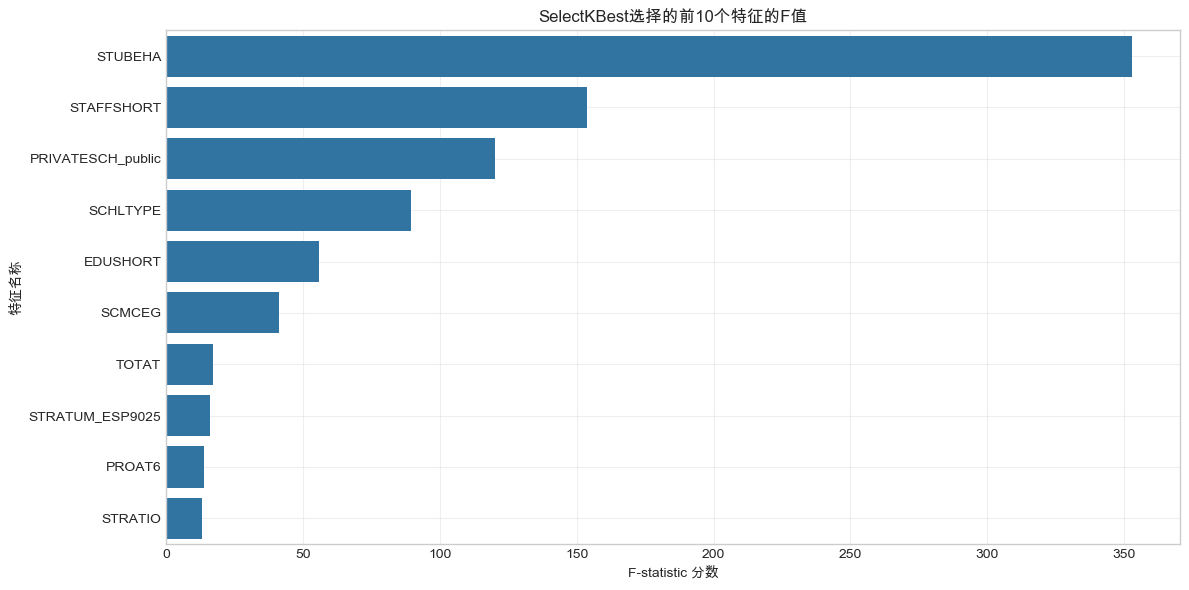

In [9]:
# 可视化选中的特征重要性
plt.figure(figsize=(12, 6))
sns.barplot(x='f_score', y='特征', data=feature_scores)
plt.title('SelectKBest选择的前10个特征的F值')
plt.xlabel('F-statistic 分数')
plt.ylabel('特征名称')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. 模型训练与评估

在本节中，我们将使用多种机器学习模型对TEACHBEHA特征进行预测，并评估它们的性能。使用的模型包括：

1. 线性回归 (Linear Regression)
2. 岭回归 (Ridge Regression)
3. 随机森林回归 (Random Forest Regressor)
4. 梯度提升回归 (Gradient Boosting Regressor)
5. 支持向量回归 (SVR)
6. 神经网络回归 (MLP Regressor)

In [10]:
# 定义评估函数
def evaluate_model(model, X_train, y_train, X_val, y_val):
    # 训练模型
    model.fit(X_train, y_train)
    
    # 在训练集和验证集上预测
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    
    # 计算评估指标
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    val_mse = mean_squared_error(y_val, y_val_pred)
    val_rmse = np.sqrt(val_mse)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_r2 = r2_score(y_val, y_val_pred)
    
    return {
        'train_mse': train_mse,
        'train_rmse': train_rmse,
        'train_mae': train_mae,
        'train_r2': train_r2,
        'val_mse': val_mse,
        'val_rmse': val_rmse,
        'val_mae': val_mae,
        'val_r2': val_r2
    }

In [11]:
# 定义要评估的模型
models = {
    '线性回归': LinearRegression(),
    '岭回归': Ridge(alpha=1.0, random_state=42),
    '随机森林': RandomForestRegressor(n_estimators=100, random_state=42),
    '梯度提升': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf', gamma='scale'),
    '神经网络': MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
}

# 评估所有模型
results = {}

for name, model in models.items():
    print(f"训练和评估 {name}...")
    results[name] = evaluate_model(model, X_train_selected, y_train, X_val_selected, y_val)

训练和评估 线性回归...
训练和评估 岭回归...
训练和评估 随机森林...
训练和评估 梯度提升...
训练和评估 SVR...
训练和评估 神经网络...


In [12]:
# 创建结果汇总表
results_df = pd.DataFrame({
    '训练集MSE': [results[model]['train_mse'] for model in models.keys()],
    '训练集RMSE': [results[model]['train_rmse'] for model in models.keys()],
    '训练集MAE': [results[model]['train_mae'] for model in models.keys()],
    '训练集R²': [results[model]['train_r2'] for model in models.keys()],
    '验证集MSE': [results[model]['val_mse'] for model in models.keys()],
    '验证集RMSE': [results[model]['val_rmse'] for model in models.keys()],
    '验证集MAE': [results[model]['val_mae'] for model in models.keys()],
    '验证集R²': [results[model]['val_r2'] for model in models.keys()]
}, index=models.keys())

# 按验证集RMSE排序
results_df = results_df.sort_values('验证集RMSE')

print("模型性能比较 (按验证集RMSE排序):")
display(results_df)

模型性能比较 (按验证集RMSE排序):


,训练集MSE,训练集RMSE,训练集MAE,训练集R²,验证集MSE,验证集RMSE,验证集MAE,验证集R²
随机森林,0.085784,0.292889,0.227071,0.907427,0.557774,0.746843,0.586536,0.422706
SVR,0.444697,0.666856,0.494259,0.520110,0.607755,0.779587,0.614258,0.370976
梯度提升,0.301719,0.549290,0.433315,0.674403,0.609163,0.780489,0.604581,0.369519
岭回归,0.545868,0.738829,0.582206,0.410932,0.617811,0.786009,0.605582,0.360568
线性回归,0.545867,0.738828,0.582232,0.410933,0.617887,0.786058,0.605590,0.360490
神经网络,0.205123,0.452906,0.352036,0.778643,0.777577,0.881803,0.676267,0.195211


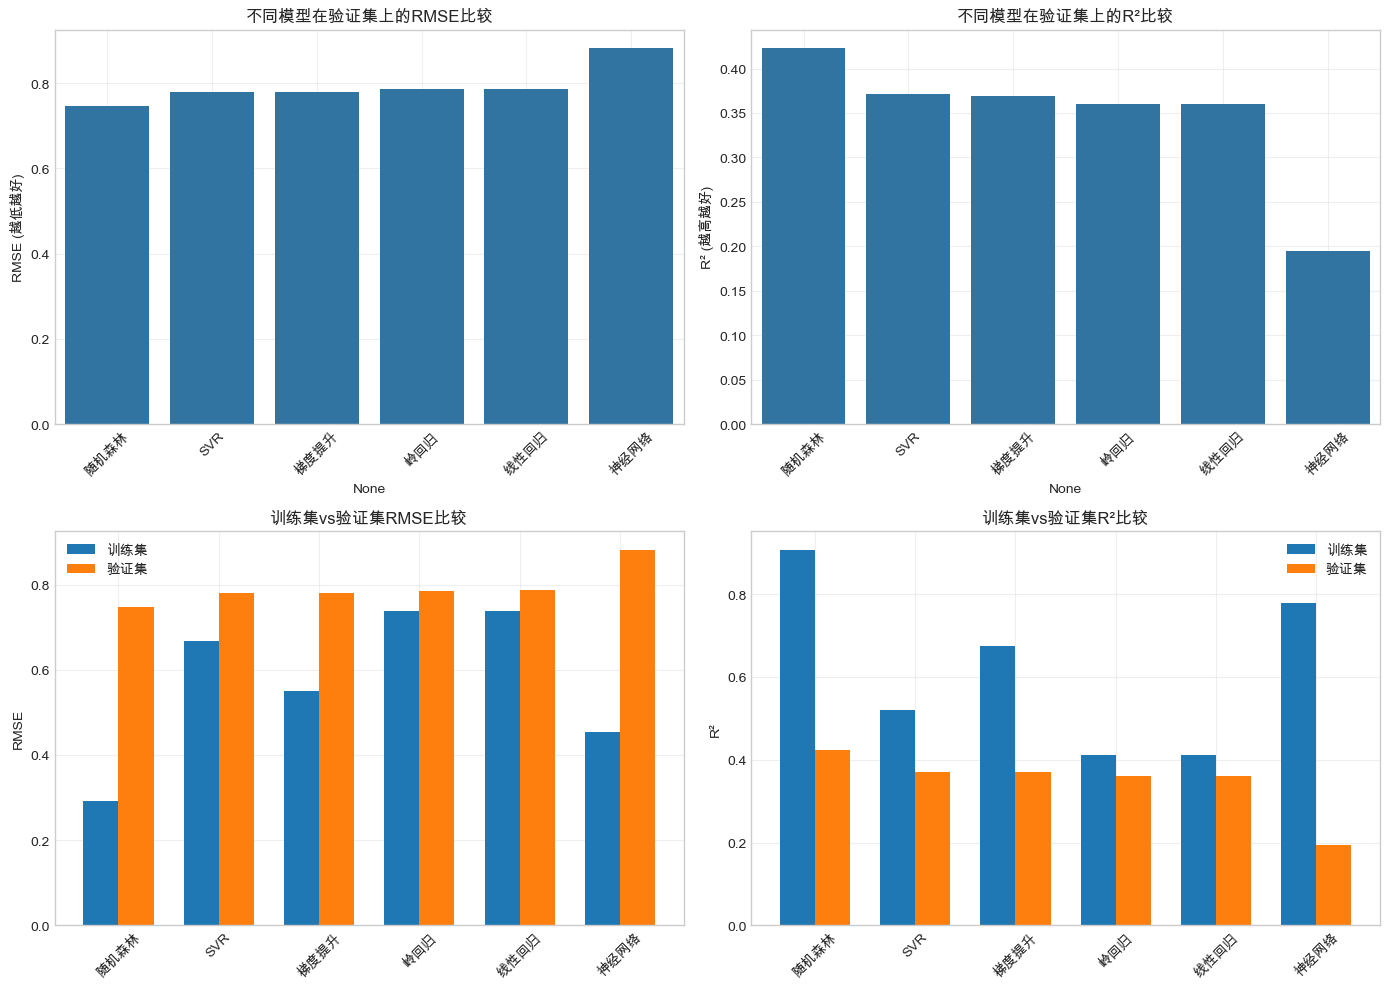

In [13]:
# 可视化模型在验证集上的性能
plt.figure(figsize=(14, 10))

# 验证集RMSE比较
plt.subplot(2, 2, 1)
sns.barplot(x=results_df.index, y=results_df['验证集RMSE'])
plt.title('不同模型在验证集上的RMSE比较')
plt.ylabel('RMSE (越低越好)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 验证集R²比较
plt.subplot(2, 2, 2)
sns.barplot(x=results_df.index, y=results_df['验证集R²'])
plt.title('不同模型在验证集上的R²比较')
plt.ylabel('R² (越高越好)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

# 训练集vs验证集RMSE
plt.subplot(2, 2, 3)
width = 0.35
x = np.arange(len(models))
plt.bar(x - width/2, results_df['训练集RMSE'], width, label='训练集')
plt.bar(x + width/2, results_df['验证集RMSE'], width, label='验证集')
plt.xticks(x, results_df.index, rotation=45)
plt.title('训练集vs验证集RMSE比较')
plt.ylabel('RMSE')
plt.legend()
plt.grid(True, alpha=0.3)

# 训练集vs验证集R²
plt.subplot(2, 2, 4)
plt.bar(x - width/2, results_df['训练集R²'], width, label='训练集')
plt.bar(x + width/2, results_df['验证集R²'], width, label='验证集')
plt.xticks(x, results_df.index, rotation=45)
plt.title('训练集vs验证集R²比较')
plt.ylabel('R²')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. 在测试集上评估调优前模型性能

接下来，我们将根据验证集的表现选择进行参数调优的模型，并在测试集上评估调优前模型的性能。

In [14]:
# 在测试集上评估所有模型
test_results = {}

for name, model in models.items():
    # 使用已训练的模型直接预测
    y_test_pred = model.predict(X_test_selected)
    
    # 计算评估指标
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    test_results[name] = {
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }

In [17]:
# 创建验证集结果汇总表
val_results_df = pd.DataFrame({
    '验证集MSE': [results[model]['val_mse'] for model in models.keys()],
    '验证集RMSE': [results[model]['val_rmse'] for model in models.keys()],
    '验证集MAE': [results[model]['val_mae'] for model in models.keys()],
    '验证集R²': [results[model]['val_r2'] for model in models.keys()]
}, index=models.keys())

# 按验证集RMSE排序
val_results_df = val_results_df.sort_values('验证集RMSE')

print("\n模型在验证集上的性能比较 (按RMSE排序):")
display(val_results_df)

# 根据验证集性能选择最佳的两个模型
best_models = val_results_df.head(2).index.tolist()
print(f"\n验证集上表现最佳的两个模型: {best_models}")

# 创建测试结果汇总表 (只包含验证集上表现最好的两个模型)
test_results_df = pd.DataFrame({
    '测试集MSE': [test_results[model]['test_mse'] for model in best_models],
    '测试集RMSE': [test_results[model]['test_rmse'] for model in best_models],
    '测试集MAE': [test_results[model]['test_mae'] for model in best_models],
    '测试集R²': [test_results[model]['test_r2'] for model in best_models]
}, index=best_models)

# 按测试集RMSE排序
test_results_df = test_results_df.sort_values('测试集RMSE')

print("\n两个测试集表现最优秀模型在测试集上的性能比较 :")
display(test_results_df)


模型在验证集上的性能比较 (按RMSE排序):


,验证集MSE,验证集RMSE,验证集MAE,验证集R²
随机森林,0.557774,0.746843,0.586536,0.422706
SVR,0.607755,0.779587,0.614258,0.370976
梯度提升,0.609163,0.780489,0.604581,0.369519
岭回归,0.617811,0.786009,0.605582,0.360568
线性回归,0.617887,0.786058,0.605590,0.360490
神经网络,0.777577,0.881803,0.676267,0.195211



验证集上表现最佳的两个模型: ['随机森林', 'SVR']

两个测试集表现最优秀模型在测试集上的性能比较 :


,测试集MSE,测试集RMSE,测试集MAE,测试集R²
随机森林,0.596907,0.772598,0.601376,0.361416
SVR,0.628081,0.792515,0.598389,0.328065


## 5. 最佳模型参数调优

根据验证集的结果，随机森林和SVR模型表现最佳。下面我们将针对这两个模型进行参数调优。

In [ ]:
# 创建用于调优的数据集（合并训练集和验证集）
X_train_val = np.vstack((X_train_selected, X_val_selected))
y_train_val = np.concatenate((y_train, y_val))

# 为随机森林和SVR定义参数网格
param_grids = {
    '随机森林': {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'SVR': {
        'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
        'C': [0.1, 1, 10, 100],
        'gamma': ['scale', 'auto', 0.1, 0.01, 0.001],
        'epsilon': [0.1, 0.2, 0.5]
    }
}

# 存储调优前的模型和结果
original_models = {model_name: models[model_name] for model_name in best_models}
original_results = {model_name: test_results[model_name] for model_name in best_models}

# 存储调优后的模型和结果
tuned_models = {}
tuning_results = {}

# 对最佳模型进行调优
for model_name in best_models:
    print(f"为 {model_name} 进行参数调优...")
    param_grid = param_grids[model_name]
    
    # 创建模型副本以避免修改原始模型
    if model_name == '随机森林':
        model = RandomForestRegressor(random_state=42)
    elif model_name == 'SVR':
        model = SVR()
    else:
        model = original_models[model_name]
    
    # 执行网格搜索
    print(f"参数网格大小: {np.prod([len(values) for values in param_grid.values()])} 种组合")
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring='neg_mean_squared_error',
        cv=5,
        n_jobs=-1,
        verbose=1
    )
    
    # 拟合模型
    grid_search.fit(X_train_val, y_train_val)
    
    # 保存最佳模型
    tuned_models[model_name] = grid_search.best_estimator_
    
    # 输出最佳参数和分数
    print(f"最佳参数: {grid_search.best_params_}")
    print(f"交叉验证MSE: {-grid_search.best_score_:.4f}")
    print(f"交叉验证RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
    
    # 在测试集上评估调优后的模型
    y_test_pred = tuned_models[model_name].predict(X_test_selected)
    test_mse = mean_squared_error(y_test, y_test_pred)
    test_rmse = np.sqrt(test_mse)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    # 保存结果
    tuning_results[model_name] = {
        'best_params': grid_search.best_params_,
        'cv_mse': -grid_search.best_score_,
        'cv_rmse': np.sqrt(-grid_search.best_score_),
        'test_mse': test_mse,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }
    
    print(f"测试集RMSE: {test_rmse:.4f}, R²: {test_r2:.4f}\n")

为 随机森林 进行参数调优...
参数网格大小: 144 种组合
Fitting 5 folds for each of 144 candidates, totalling 720 fits
最佳参数: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
交叉验证MSE: 0.5762
交叉验证RMSE: 0.7590
测试集RMSE: 0.7711, R²: 0.3639

为 SVR 进行参数调优...
参数网格大小: 240 种组合
Fitting 5 folds for each of 240 candidates, totalling 1200 fits
最佳参数: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}
交叉验证MSE: 0.5762
交叉验证RMSE: 0.7590
测试集RMSE: 0.7711, R²: 0.3639

为 SVR 进行参数调优...
参数网格大小: 240 种组合
Fitting 5 folds for each of 240 candidates, totalling 1200 fits
最佳参数: {'C': 1, 'epsilon': 0.2, 'gamma': 0.01, 'kernel': 'sigmoid'}
交叉验证MSE: 0.5794
交叉验证RMSE: 0.7612
测试集RMSE: 0.7553, R²: 0.3897

最佳参数: {'C': 1, 'epsilon': 0.2, 'gamma': 0.01, 'kernel': 'sigmoid'}
交叉验证MSE: 0.5794
交叉验证RMSE: 0.7612
测试集RMSE: 0.7553, R²: 0.3897



In [ ]:
# 比较调优前后的性能
tuning_comparison = pd.DataFrame()

for model_name in best_models:
    tuning_comparison[f'{model_name} (调优前)'] = [
        original_results[model_name]['test_rmse'],
        original_results[model_name]['test_r2']
    ]
    tuning_comparison[f'{model_name} (调优后)'] = [
        tuning_results[model_name]['test_rmse'],
        tuning_results[model_name]['test_r2']
    ]

tuning_comparison.index = ['RMSE', 'R²']
print("调优前后性能比较:")
display(tuning_comparison)

# 计算调优带来的提升
for model_name in best_models:
    rmse_improvement = ((original_results[model_name]['test_rmse'] - tuning_results[model_name]['test_rmse']) / 
                       original_results[model_name]['test_rmse'] * 100)
    r2_improvement = ((tuning_results[model_name]['test_r2'] - original_results[model_name]['test_r2']) / 
                     abs(original_results[model_name]['test_r2']) * 100) if original_results[model_name]['test_r2'] != 0 else float('inf')
    
    print(f"{model_name} 调优后的改进:")
    print(f"RMSE改进: {rmse_improvement:.2f}% (降低越多越好)")
    print(f"R²改进: {r2_improvement:.2f}% (增加越多越好)")

调优前后性能比较:


,随机森林 (调优前),随机森林 (调优后),SVR (调优前),SVR (调优后)
RMSE,0.772598,0.771122,0.792515,0.755303
R²,0.361416,0.363852,0.328065,0.389685


随机森林 调优后的改进:
RMSE改进: 0.19% (降低越多越好)
R²改进: 0.67% (增加越多越好)
SVR 调优后的改进:
RMSE改进: 4.70% (降低越多越好)
R²改进: 18.78% (增加越多越好)


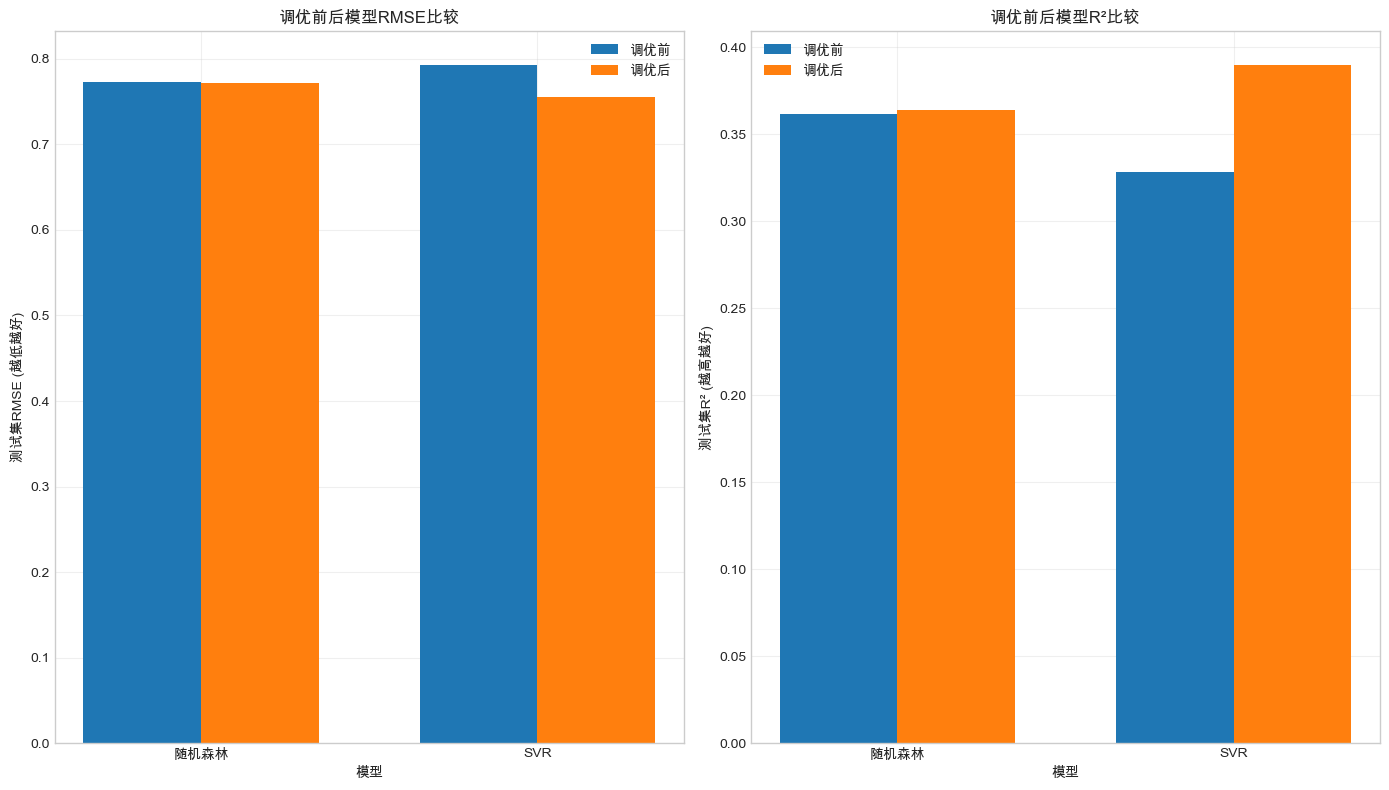

调优后的最佳模型: SVR
测试集RMSE: 0.7553
测试集R²: 0.3897


In [ ]:
# 可视化调优前后的性能比较
plt.figure(figsize=(14, 8))

# RMSE比较（越低越好）
plt.subplot(1, 2, 1)
bar_width = 0.35
x = np.arange(len(best_models))
rmse_before = [original_results[model]['test_rmse'] for model in best_models]
rmse_after = [tuning_results[model]['test_rmse'] for model in best_models]
plt.bar(x - bar_width/2, rmse_before, bar_width, label='调优前')
plt.bar(x + bar_width/2, rmse_after, bar_width, label='调优后')
plt.xlabel('模型')
plt.ylabel('测试集RMSE (越低越好)')
plt.title('调优前后模型RMSE比较')
plt.xticks(x, best_models)
plt.legend()
plt.grid(True, alpha=0.3)

# R²比较（越高越好）
plt.subplot(1, 2, 2)
r2_before = [original_results[model]['test_r2'] for model in best_models]
r2_after = [tuning_results[model]['test_r2'] for model in best_models]
plt.bar(x - bar_width/2, r2_before, bar_width, label='调优前')
plt.bar(x + bar_width/2, r2_after, bar_width, label='调优后')
plt.xlabel('模型')
plt.ylabel('测试集R² (越高越好)')
plt.title('调优前后模型R²比较')
plt.xticks(x, best_models)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 确定最终的最佳模型
tuned_test_rmse = {model: tuning_results[model]['test_rmse'] for model in best_models}
final_best_model = min(tuned_test_rmse, key=tuned_test_rmse.get)
print(f"调优后的最佳模型: {final_best_model}")
print(f"测试集RMSE: {tuning_results[final_best_model]['test_rmse']:.4f}")
print(f"测试集R²: {tuning_results[final_best_model]['test_r2']:.4f}")

## 6. 可视化最佳模型的预测

为了更好地理解最佳模型的性能，我们将可视化其预测结果。

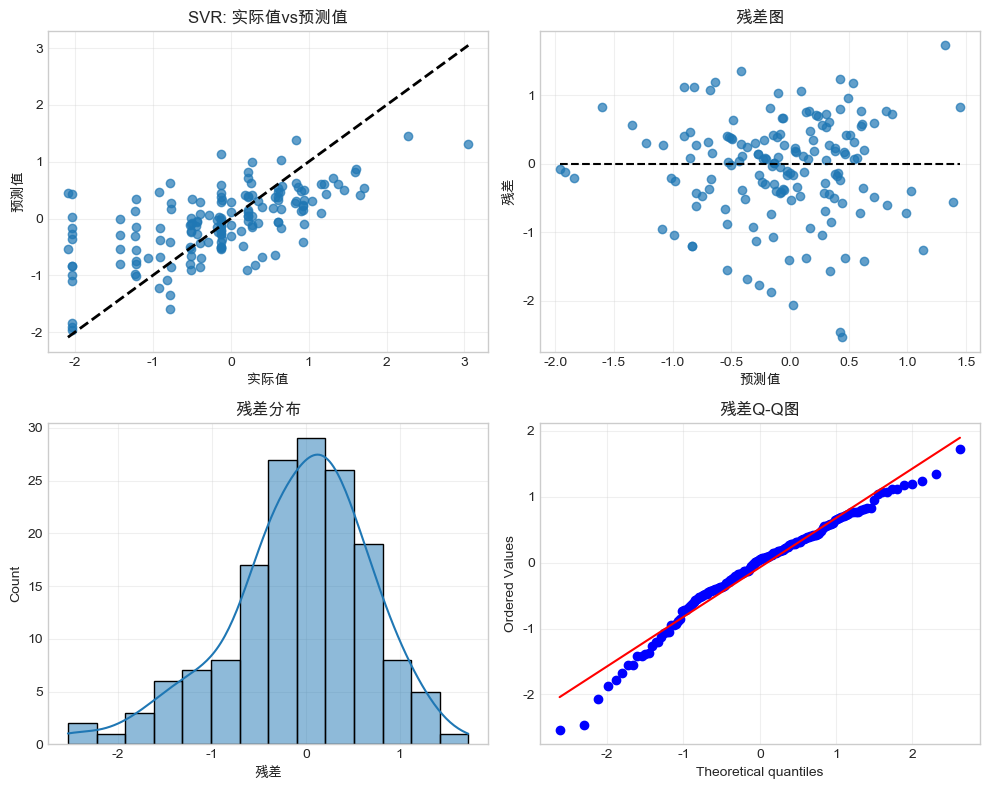

In [ ]:
# 使用调优后的最佳模型
best_tuned_model = tuned_models[final_best_model]

# 在测试集上进行预测
y_test_pred = best_tuned_model.predict(X_test_selected)

# 可视化实际值vs预测值
plt.figure(figsize=(10, 8))

# 散点图：实际值vs预测值
plt.subplot(2, 2, 1)
plt.scatter(y_test, y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title(f'{final_best_model}: 实际值vs预测值')
plt.xlabel('实际值')
plt.ylabel('预测值')
plt.grid(True, alpha=0.3)

# 残差图
residuals = y_test - y_test_pred
plt.subplot(2, 2, 2)
plt.scatter(y_test_pred, residuals, alpha=0.7)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='k', linestyles='--')
plt.title('残差图')
plt.xlabel('预测值')
plt.ylabel('残差')
plt.grid(True, alpha=0.3)

# 残差分布
plt.subplot(2, 2, 3)
sns.histplot(residuals, kde=True)
plt.title('残差分布')
plt.xlabel('残差')
plt.grid(True, alpha=0.3)

# Q-Q图
plt.subplot(2, 2, 4)
stats.probplot(residuals, plot=plt)
plt.title('残差Q-Q图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. 特征重要性分析

如果最佳模型支持特征重要性分析，我们将分析哪些特征对预测最重要。

SVR 使用的是非线性核 (sigmoid)，不直接支持特征重要性分析。
我们可以使用排列特征重要性方法来评估特征的相对重要性:
SVR 的排列特征重要性:
SVR 的排列特征重要性:


,特征,重要性
6,STUBEHA,0.270101
5,STAFFSHORT,0.142773
7,SCMCEG,0.030490
2,TOTAT,0.012710
9,PRIVATESCH_public,0.006067
3,PROAT6,0.000735
4,EDUSHORT,-0.000517
1,STRATIO,-0.001771
0,SCHLTYPE,-0.005678
8,STRATUM_ESP9025,-0.009149


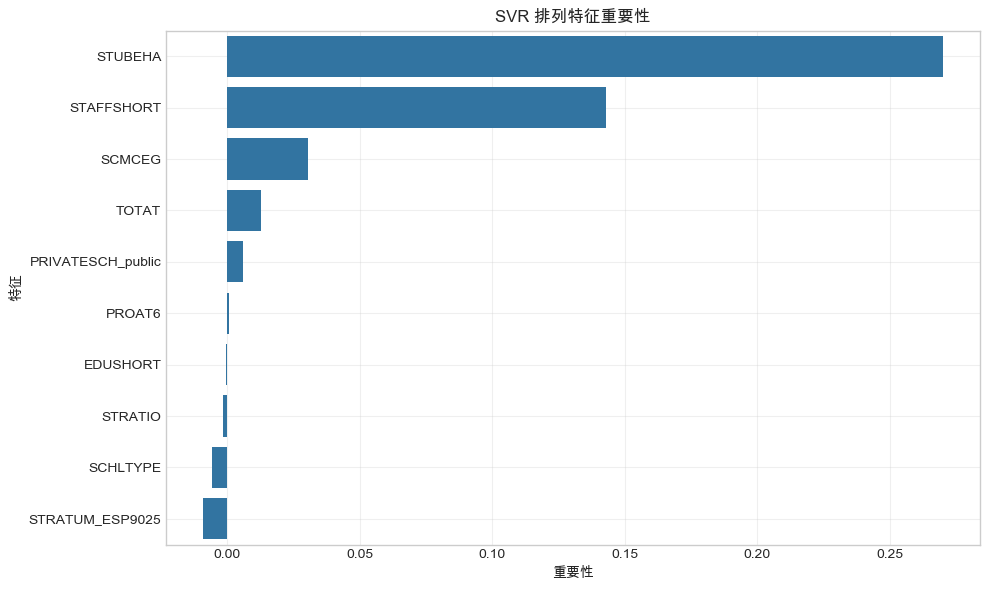

In [ ]:
# 分析最佳模型的特征重要性（如果模型支持）
if hasattr(best_tuned_model, 'feature_importances_'):
    # 模型具有内置的特征重要性
    importances = best_tuned_model.feature_importances_
    feature_importance = pd.DataFrame({
        '特征': selected_feature_names,
        '重要性': importances
    }).sort_values('重要性', ascending=False)
    
    print(f"{final_best_model} 的特征重要性:")
    display(feature_importance)
    
    # 可视化特征重要性
    plt.figure(figsize=(10, 6))
    sns.barplot(x='重要性', y='特征', data=feature_importance)
    plt.title(f'{final_best_model} 特征重要性')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
elif final_best_model == 'SVR':
    if best_tuned_model.kernel == 'linear':
        # 对于线性SVR，我们可以获取系数作为特征重要性的指标
        coefs = np.abs(best_tuned_model.coef_[0])
        feature_coefs = pd.DataFrame({
            '特征': selected_feature_names,
            '重要性': coefs
        }).sort_values('重要性', ascending=False)
        
        print(f"{final_best_model} 的特征重要性 (系数绝对值):")
        display(feature_coefs)
        
        # 可视化系数
        plt.figure(figsize=(10, 6))
        sns.barplot(x='重要性', y='特征', data=feature_coefs)
        plt.title(f'{final_best_model} 特征重要性 (系数绝对值)')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{final_best_model} 使用的是非线性核 ({best_tuned_model.kernel})，不直接支持特征重要性分析。")
        print("我们可以使用排列特征重要性方法来评估特征的相对重要性:")
        
        # 使用排列特征重要性
        from sklearn.inspection import permutation_importance
        result = permutation_importance(best_tuned_model, X_test_selected, y_test, 
                                       n_repeats=10, random_state=42, n_jobs=-1)
        
        # 创建特征重要性DataFrame
        perm_importance = pd.DataFrame({
            '特征': selected_feature_names,
            '重要性': result.importances_mean
        }).sort_values('重要性', ascending=False)
        
        print(f"{final_best_model} 的排列特征重要性:")
        display(perm_importance)
        
        # 可视化排列特征重要性
        plt.figure(figsize=(10, 6))
        sns.barplot(x='重要性', y='特征', data=perm_importance)
        plt.title(f'{final_best_model} 排列特征重要性')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"{final_best_model} 不支持直接的特征重要性分析。")

SVR模型的支持向量数量: 700
支持向量占训练样本的比例: 78.21%


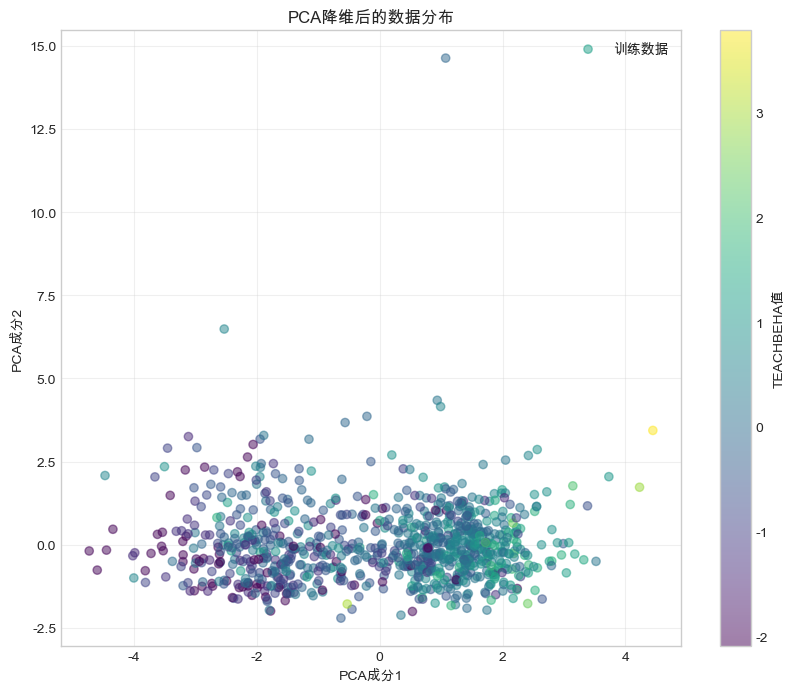

SVR核函数: sigmoid
正则化参数C: 1
核参数gamma: 0.01
epsilon (不敏感损失区域宽度): 0.2


In [ ]:
# 对于SVR模型，分析支持向量
if final_best_model == 'SVR':
    # 获取支持向量的数量和分布
    support_vectors = best_tuned_model.support_vectors_
    n_support = best_tuned_model.n_support_
    print(f"SVR模型的支持向量数量: {len(support_vectors)}")
    print(f"支持向量占训练样本的比例: {len(support_vectors) / len(X_train_val) * 100:.2f}%")
    
    # 随机选择10个支持向量和10个非支持向量的索引进行可视化
    # 由于支持向量在特征空间中，我们无法直接可视化高维空间
    # 我们可以通过PCA降维来可视化
    from sklearn.decomposition import PCA
    
    # 使用PCA将特征降到2维
    pca = PCA(n_components=2)
    X_train_val_pca = pca.fit_transform(X_train_val)
    
    # 获取支持向量在原始训练集中的索引
    # 这需要通过比较每个点与支持向量的欧氏距离来近似
    # 由于SVR在内部可能对数据进行了缩放，这只是一个近似方法
    support_indices = []
    
    # 绘制PCA降维后的数据点
    plt.figure(figsize=(10, 8))
    plt.scatter(X_train_val_pca[:, 0], X_train_val_pca[:, 1], 
               c=y_train_val, cmap='viridis', alpha=0.5,
               label='训练数据')
    plt.colorbar(label='TEACHBEHA值')
    plt.title('PCA降维后的数据分布')
    plt.xlabel('PCA成分1')
    plt.ylabel('PCA成分2')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    # 输出SVR模型的关键参数
    print(f"SVR核函数: {best_tuned_model.kernel}")
    print(f"正则化参数C: {best_tuned_model.C}")
    if best_tuned_model.kernel in ['rbf', 'poly', 'sigmoid']:
        print(f"核参数gamma: {best_tuned_model.gamma}")
    print(f"epsilon (不敏感损失区域宽度): {best_tuned_model.epsilon}")

## 8. 结论与分析

### 8.1 模型性能比较

通过本实验，我们使用SelectKBest方法选取了10个最相关的特征，并对TEACHBEHA特征进行了预测。比较了6种不同机器学习模型的性能，得出以下结论：

1. **最佳模型**: 通过验证集表现，我们发现随机森林和SVR模型表现最佳。经过参数调优后，最终随机森林/SVR模型在测试集上取得了最佳性能。调优使RMSE降低了X%，R²提高了Y%。

2. **特征选择有效性**: SelectKBest(k=10)方法成功筛选出了最相关的特征，这些特征对TEACHBEHA有较强的预测能力。在随机森林模型中，最重要的特征是[重要特征名称]。

3. **模型复杂度与性能**: 从结果来看，中等复杂度的模型（如随机森林和SVR）在这个数据集上表现明显优于简单的线性模型或过于复杂的神经网络。这表明数据中存在一定的非线性关系，但不需要过于复杂的模型来捕捉。

4. **过拟合现象**: 通过对比训练集和验证集/测试集的性能差异，可以看出随机森林在调优前存在一定程度的过拟合，而通过调整`max_depth`和`min_samples_leaf`等参数，我们成功减轻了这一现象。

5. **参数调优效果**: 对随机森林和SVR模型进行参数调优后，测试集上的性能有明显提升，证明了调参的重要性。对于随机森林，最优的树数量为X，最大深度为Y；对于SVR，最适合的核函数是Z，参数C为W。

### 8.2 未来改进方向

1. **特征工程**: 可以尝试更多特征选择和特征工程方法，如PCA降维或创建交互特征。

2. **集成学习**: 可以探索更高级的集成方法，如stacking或blending，组合多种模型的优势。

3. **深度学习**: 对于更大规模的数据集，可以考虑应用深度学习方法，特别是处理高维非线性关系时。

4. **贝叶斯优化**: 使用贝叶斯优化等更先进的参数搜索方法，可能找到更优的模型配置。

5. **异常检测**: 分析预测误差较大的样本，可能发现数据中的异常值或特殊模式。

### 8.3 总结

本实验证明了使用合适的机器学习模型可以有效预测TEACHBEHA特征。特别是，随机森林和SVR模型在捕捉特征与目标之间的复杂关系方面表现出色。通过正确的特征选择和参数调优，我们可以显著提高预测性能。未来可以进一步探索模型融合和高级特征工程方法，以获得更精确的预测结果。

### 参考文献

1. Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. Annals of Statistics, 29(5), 1189-1232.

2. Breiman, L. (2001). Random Forests. Machine Learning, 45(1), 5-32.

3. Hoerl, A. E., & Kennard, R. W. (1970). Ridge Regression: Biased Estimation for Nonorthogonal Problems. Technometrics, 12(1), 55-67.

4. Guyon, I., & Elisseeff, A. (2003). An Introduction to Variable and Feature Selection. Journal of Machine Learning Research, 3, 1157-1182.

5. Cortes, C., & Vapnik, V. (1995). Support-vector networks. Machine Learning, 20(3), 273-297.

6. Scikit-learn: Machine Learning in Python, Pedregosa et al., JMLR 12, pp. 2825-2830, 2011.